<a href="https://colab.research.google.com/github/sauravk21/cv_tutorial/blob/main/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Code a NN from scratch

import numpy as np
from numpy.random import randn

N, D_in, H, D_out = 64, 1000, 100, 10
x, y = np.random.randn(N,D_in), np.random.randn(N,D_out)
w1, w2 = np.random.randn(D_in,H), np.random.randn(H,D_out)


for t in range(2000):
  h = 1/ (1+np.exp(-x.dot(w1)))
  y_pred = h.dot(w2)
  loss = np.square(y_pred - y).sum()

  grad_y_pred = 2.0*(y_pred - y)
  grad_w2 = h.T.dot(grad_y_pred)
  grad_h = grad_y_pred.dot(w2.T)
  grad_w1 = x.T.dot(grad_h * h * (1-h))

  w1-= 1e-4 * grad_w1
  w2-= 1e-4 * grad_w2



0 26403.038975401567
1 19160.381223358734
2 15785.261527783043
3 14064.947443840587
4 13024.62759342236
5 12257.337474122663
6 11625.364185308
7 11118.845651825537
8 10689.601145910287
9 10330.327961719457
10 10032.54572412743
11 9760.476480839334
12 9502.516981935569
13 9275.034293378707
14 9060.915457611432
15 8858.399289185298
16 8678.411492400694
17 8512.189869195694
18 8350.23966886035
19 8188.874923034558
20 8030.588551558336
21 7876.000228507344
22 7729.991179679142
23 7593.893610657048
24 7462.895542468703
25 7334.101768252829
26 7207.672888175637
27 7086.501553534131
28 6973.001151662063
29 6865.350922146305
30 6760.278021969135
31 6654.957398000584
32 6548.269329049703
33 6443.956431707291
34 6343.10748184204
35 6242.5557779163355
36 6142.399556762651
37 6045.361526848306
38 5950.23020058355
39 5853.686265137856
40 5754.651928608404
41 5653.340128638526
42 5560.595499210693
43 5476.56789436922
44 5395.945770228844
45 5318.310383721167
46 5243.149574008945
47 5169.1380964843
4

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = "data",
    train="True",
    download="True",
    transform = ToTensor()
)

test_data = datasets.FashionMNIST(
    root = "data",
    train="False",
    download="True",
    transform = ToTensor()
)


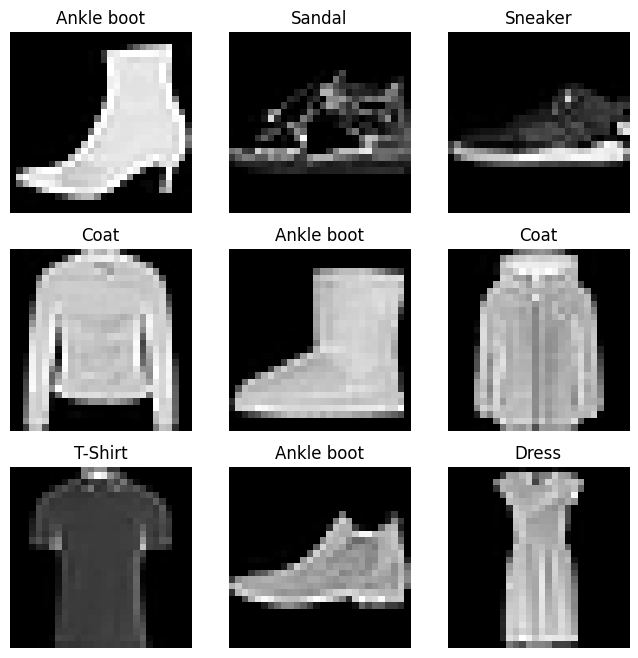

In [ ]:
import random

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

figure = plt.figure(figsize=(8,8))

cols, rows = 3, 3
for i in range(1,cols*rows+1):
  sample_idx = random.randint(0, len(training_data) - 1)
  img, label = training_data[sample_idx]
  figure.add_subplot(rows,cols,i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(),cmap="gray")
plt.show()

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)


In [ ]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork,self).__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Linear(512,10),
        nn.ReLU()
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
    (5): ReLU()
  )
)


In [ ]:
X = torch.rand(1,28,28,device = device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([7])


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)

def train_loop(dataloader,model,loss_fn,optimizer):
  size = len(dataloader.dataset)
  for batch,(X,y) in enumerate(dataloader):
    pred = model(X)
    loss = loss_fn(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch%100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [ ]:
def test_loop(dataloader,model,loss_fn):
  size = len(dataloader.dataset)
  test_loss, correct = 0 , 0

  with torch.no_grad():
    for X,y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred,y).item()
      correct+= (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss/=size
  correct/=size
  print(f"Test Error: \n Accuracy: {(100*correct) :>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
epochs = 10
for t in range(epochs):
  print(f"Epoch {t+1}\n--------------")
  train_loop(train_dataloader,model,loss_fn,optimizer)
  test_loop(test_dataloader,model,loss_fn)

print("Completed")

Epoch 1
--------------
loss: 2.220766 [    0/60000]
loss: 2.208433 [ 6400/60000]
loss: 2.222858 [12800/60000]
loss: 2.162421 [19200/60000]
loss: 2.189749 [25600/60000]
loss: 2.147256 [32000/60000]
loss: 2.123352 [38400/60000]
loss: 2.129092 [44800/60000]
loss: 2.041677 [51200/60000]
loss: 2.151779 [57600/60000]
Test Error: 
 Accuracy: 41.7%, Avg loss: 0.032677 

Epoch 2
--------------
loss: 2.125523 [    0/60000]
loss: 2.069312 [ 6400/60000]
loss: 2.022708 [12800/60000]
loss: 2.051224 [19200/60000]
loss: 2.017116 [25600/60000]
loss: 2.003877 [32000/60000]
loss: 1.952697 [38400/60000]
loss: 1.931414 [44800/60000]
loss: 1.976127 [51200/60000]
loss: 1.949790 [57600/60000]
Test Error: 
 Accuracy: 41.8%, Avg loss: 0.029923 

Epoch 3
--------------
loss: 1.883817 [    0/60000]
loss: 2.003652 [ 6400/60000]
loss: 1.799878 [12800/60000]
loss: 1.734206 [19200/60000]
loss: 1.878306 [25600/60000]
loss: 1.913847 [32000/60000]
loss: 1.696828 [38400/60000]
loss: 1.945534 [44800/60000]
loss: 1.711647 

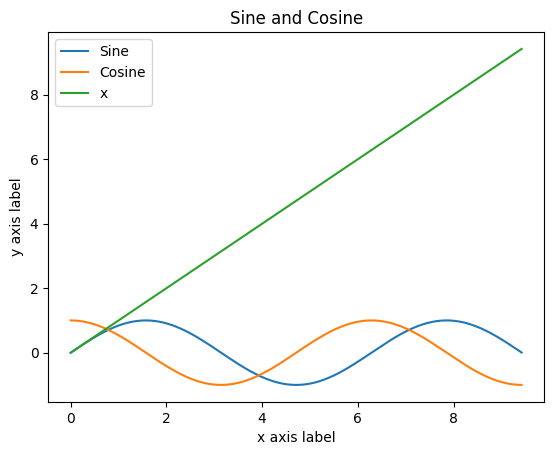

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0,3*np.pi,0.01)
y_sin = np.sin(x)
y_cos = np.cos(x)
y = x

plt.plot(x,y_sin)
plt.plot(x,y_cos)
plt.plot(x,y)
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.title('Sine and Cosine')
plt.legend(['Sine','Cosine','x'])
plt.show()

In [ ]:
import torch
import numpy as np
import math

x = torch.tensor([[1,2],[3,4]],dtype = torch.float32)
print("x:",x)

y = torch.zeros(2,2)
print("y:",y)

z = torch.rand(2,2)
print("z:",z)

np_array = np.array([1,2,3])
x_np = torch.from_numpy(np_array)
print("x_np:",x_np)

x: tensor([[1., 2.],
        [3., 4.]])
y: tensor([[0., 0.],
        [0., 0.]])
z: tensor([[0.5189, 0.9397],
        [0.9441, 0.6571]])
x_np: tensor([1, 2, 3])


In [ ]:
tensor = torch.tensor()